**Cell 1 — Imports**

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Cell 2 — Load Data**

In [30]:
df = pd.read_csv("../data/processed/steam_merged.csv")
print(df.shape)
print(df.dtypes)

(612265, 16)
month                object
avg_players         float64
gain                 object
gain_percent        float64
peak_players          int64
name_x               object
steam_appid           int64
release_date         object
genres               object
steamspy_tags        object
positive_ratings    float64
negative_ratings    float64
average_playtime    float64
median_playtime     float64
owners               object
price               float64
dtype: object


**Cell 3 — Type Fixes & Renaming**

In [31]:
# Fix datetime columns
df['month'] = pd.to_datetime(df['month'], format='%b-%y')
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Fix gain column
df['gain'] = pd.to_numeric(df['gain'].str.replace(',', ''), errors='coerce')

# Rename for clarity
df.rename(columns={'name_x': 'game_name'}, inplace=True)

print(df.dtypes)
print(df.shape)

month               datetime64[ns]
avg_players                float64
gain                       float64
gain_percent               float64
peak_players                 int64
game_name                   object
steam_appid                  int64
release_date        datetime64[ns]
genres                      object
steamspy_tags               object
positive_ratings           float64
negative_ratings           float64
average_playtime           float64
median_playtime            float64
owners                      object
price                      float64
dtype: object
(612265, 16)


**Cell 4 — Parse Owners**

In [32]:
def parse_owners(val):
    if pd.isna(val):
        return np.nan
    val = str(val).replace(',', '').replace(' ', '')
    parts = val.split('-')
    try:
        return (int(parts[0]) + int(parts[-1])) / 2
    except:
        return np.nan

df['owners_est'] = df['owners'].apply(parse_owners)

# Fill NaNs with median
df['owners_est'] = df['owners_est'].fillna(df['owners_est'].median())

print(df['owners_est'].describe())
print(df['owners_est'].isna().sum())

count    6.122650e+05
mean     6.072725e+05
std      2.293988e+06
min      1.000000e+04
25%      3.500000e+04
50%      1.500000e+05
75%      3.500000e+05
max      7.500000e+07
Name: owners_est, dtype: float64
0


**Cell 5 — Real Derived Features**

In [33]:
# Game age in months at time of each monthly record
df['game_age_months'] = (df['month'] - df['release_date']).dt.days / 30
df['game_age_months'] = df['game_age_months'].clip(lower=0)
df['game_age_months'] = df['game_age_months'].fillna(df['game_age_months'].median())

# Sentiment ratio
total_ratings = df['positive_ratings'] + df['negative_ratings']
df['sentiment_ratio'] = df['positive_ratings'] / total_ratings.replace(0, np.nan)
df['sentiment_ratio'] = df['sentiment_ratio'].fillna(0.5)  # neutral default

# Drop-off rate
df['dropoff_rate'] = 1 - (df['avg_players'] / df['peak_players'].replace(0, np.nan))
df['dropoff_rate'] = df['dropoff_rate'].clip(0, 1)
df['dropoff_rate'] = df['dropoff_rate'].fillna(df['dropoff_rate'].median())

# Cheat-prone genre flag
cheat_prone_tags = [
    'fps', 'shooter', 'action', 'multiplayer',
    'competitive', 'battle royale', 'first-person'
]

def is_cheat_prone(tags):
    if pd.isna(tags):
        return 0
    return int(any(tag in str(tags).lower() for tag in cheat_prone_tags))

df['cheat_prone'] = df['steamspy_tags'].apply(is_cheat_prone)

print(df[['game_age_months', 'sentiment_ratio', 'dropoff_rate', 'cheat_prone']].describe())

       game_age_months  sentiment_ratio   dropoff_rate    cheat_prone
count    612265.000000    612265.000000  612265.000000  612265.000000
mean         61.886689         0.761905       0.667315       0.324309
std          44.663532         0.165356       0.155579       0.468116
min           0.000000         0.000000       0.000000       0.000000
25%          27.700000         0.660207       0.557419       0.000000
50%          55.466667         0.803922       0.663333       0.000000
75%          86.500000         0.895000       0.769091       1.000000
max         343.000000         1.000000       1.000000       1.000000


**Cell 6 — Normalize Features**

In [34]:
# Game age normalization
df['game_age_norm'] = df['game_age_months'] / df['game_age_months'].max()

# Owners log normalization (handles huge range)
df['owners_log'] = np.log1p(df['owners_est'])
log_min = df['owners_log'].min()
log_max = df['owners_log'].max()
df['owners_norm'] = (df['owners_log'] - log_min) / (log_max - log_min)

# Price NaN fill
df['price'] = df['price'].fillna(df['price'].median())

print(df[['game_age_norm', 'owners_norm', 'price']].describe())

       game_age_norm    owners_norm          price
count  612265.000000  612265.000000  612265.000000
mean        0.180428       0.286716      10.093036
std         0.130214       0.194732       9.861483
min         0.000000       0.000000       0.000000
25%         0.080758       0.140396       4.250000
50%         0.161710       0.303496       7.190000
75%         0.252187       0.398456      14.990000
max         1.000000       1.000000     209.990000


**Cell 7 — Synthetic Variables**

In [35]:
np.random.seed(42)

# Base cheat rate anchored to real signals
df['base_cheat_rate'] = (
    0.35 * df['cheat_prone'] +
    0.30 * df['dropoff_rate'] +
    0.20 * df['game_age_norm'] +
    0.15 * (1 - df['sentiment_ratio'])
)

# Add noise
df['cheat_rate'] = (
    df['base_cheat_rate'] + np.random.normal(0, 0.02, size=len(df))
).clip(0, 1)

# Revenue impact score
df['revenue_impact_score'] = (
    df['owners_norm'] *
    (df['price'].clip(upper=60) / 60) *
    (1 - df['cheat_rate'] * 0.7)
).clip(0, 1)

print(df[['cheat_rate', 'dropoff_rate', 'sentiment_ratio', 'revenue_impact_score']].describe())

          cheat_rate   dropoff_rate  sentiment_ratio  revenue_impact_score
count  612265.000000  612265.000000    612265.000000         612265.000000
mean        0.385471       0.667315         0.761905              0.035416
std         0.176416       0.155579         0.165356              0.048006
min         0.019695       0.000000         0.000000              0.000000
25%         0.250204       0.557419         0.660207              0.000000
50%         0.307058       0.663333         0.803922              0.023172
75%         0.581796       0.769091         0.895000              0.046119
max         0.884008       1.000000         1.000000              0.490139


**Cell 8 — Sanity Checks**

In [36]:
# NaN check
print("=== NaN Counts ===")
print(df[['cheat_rate', 'dropoff_rate', 'sentiment_ratio', 'revenue_impact_score']].isna().sum())

# Correlation check
print("\n=== Correlations ===")
print(df[['cheat_rate', 'dropoff_rate', 'sentiment_ratio', 'revenue_impact_score']].corr())

=== NaN Counts ===
cheat_rate              0
dropoff_rate            0
sentiment_ratio         0
revenue_impact_score    0
dtype: int64

=== Correlations ===
                      cheat_rate  dropoff_rate  sentiment_ratio  \
cheat_rate              1.000000      0.299757        -0.095973   
dropoff_rate            0.299757      1.000000        -0.128894   
sentiment_ratio        -0.095973     -0.128894         1.000000   
revenue_impact_score   -0.143413     -0.333291         0.118378   

                      revenue_impact_score  
cheat_rate                       -0.143413  
dropoff_rate                     -0.333291  
sentiment_ratio                   0.118378  
revenue_impact_score              1.000000  


**Cell 9 — Quick Validation Plots**

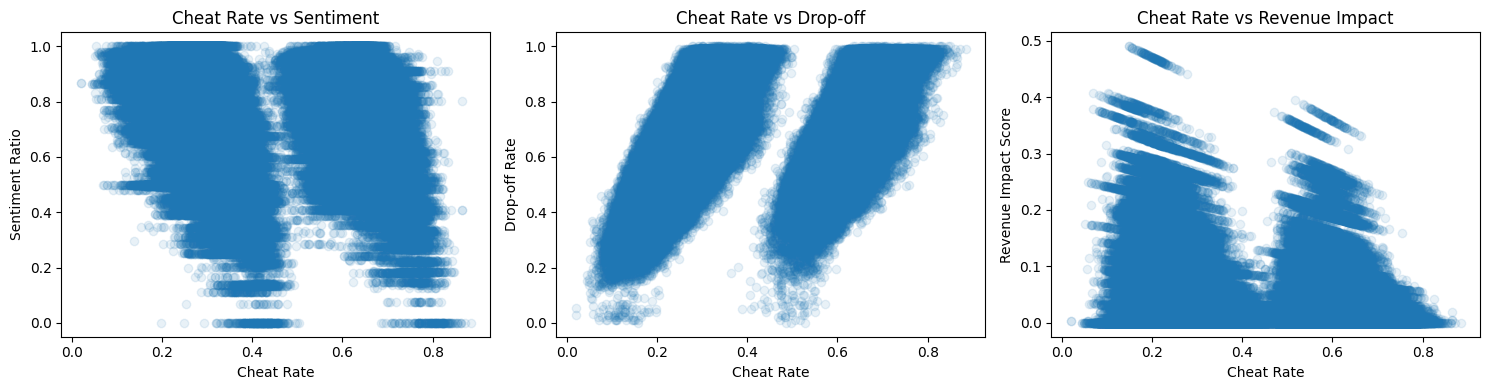

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df['cheat_rate'], df['sentiment_ratio'], alpha=0.1)
axes[0].set_xlabel('Cheat Rate')
axes[0].set_ylabel('Sentiment Ratio')
axes[0].set_title('Cheat Rate vs Sentiment')

axes[1].scatter(df['cheat_rate'], df['dropoff_rate'], alpha=0.1)
axes[1].set_xlabel('Cheat Rate')
axes[1].set_ylabel('Drop-off Rate')
axes[1].set_title('Cheat Rate vs Drop-off')

axes[2].scatter(df['cheat_rate'], df['revenue_impact_score'], alpha=0.1)
axes[2].set_xlabel('Cheat Rate')
axes[2].set_ylabel('Revenue Impact Score')
axes[2].set_title('Cheat Rate vs Revenue Impact')

plt.tight_layout()
#plt.savefig('images/synthetic_validation.png', dpi=150)
plt.show()

**Cell 10 — Save Processed Data**

In [38]:
df.to_csv('../data/processed/processed_dataset.csv', index=False)
print("Saved to data/processed/processed_dataset.csv")
print(df.shape)

Saved to data/processed/processed_dataset.csv
(612265, 27)
